# **EXPERIMENT-11** -Sprinkler

**AIM:** To construct and analyze a Bayesian Network using the pgmpy library for probabilistic inference on the Sprinkler–Rain–WetGrass data and compute conditional probabilities using the Variable Elimination algorithm.







**Problem Description (Sprinkler Example):**

This Bayesian Network models a simple weather scenario:
 * Cloudy → Weather condition
 * Sprinkler → Whether the garden sprinkler is on
 * Rain → Whether it is raining
 * WetGrass → Whether the grass is wet

**Dependencies:**

 * Cloudy affects both Rain and Sprinkler.
 * Rain affects WetGrass.
 * Sprinkler affects WetGrass.

Example reasoning:

If the grass is wet, it may be because of rain or sprinkler.

In [ ]:
!pip install pgmpy

import pandas as pd
import numpy as np

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

import networkx as nx
import matplotlib.pyplot as plt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 31.6 MB/s eta 0:00:00


**Define the Network Structure:**
This step defines the dependency structure of the Bayesian Network.
**Relationships:**
 * Cloudy → Sprinkler

   If it is cloudy, the sprinkler may be turned off.
 * Cloudy → Rain

   Cloudy weather increases the probability of rain.
 * Sprinkler → WetGrass

   If the sprinkler is on, the grass becomes wet.
 * Rain → WetGrass

   Rain also makes the grass wet.

This structure forms a Directed Acyclic Graph (DAG).

In [ ]:
model = DiscreteBayesianNetwork([
    ('Cloudy', 'Sprinkler'),
    ('Cloudy', 'Rain'),
    ('Sprinkler', 'WetGrass'),
    ('Rain', 'WetGrass')
])

**Visualize the Bayesian Network:**

This code visualizes the Bayesian Network structure.
* DiGraph() creates a directed graph.
* spring_layout() positions nodes automatically.
* nx.draw() displays nodes and arrows representing dependencies.

Arrows indicate causal relationships between variables.

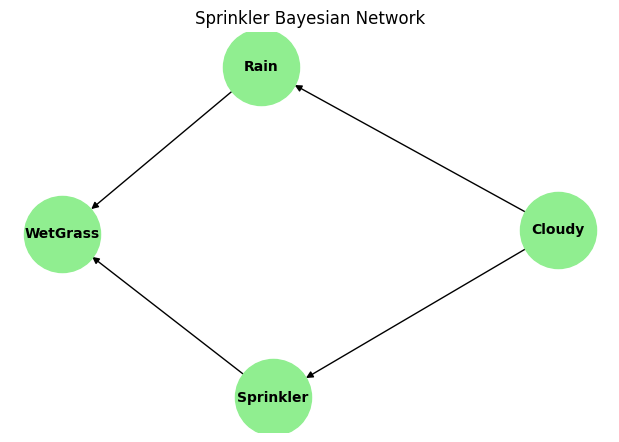

In [ ]:
plt.figure(figsize=(6,4))
G = nx.DiGraph(model.edges())
pos = nx.spring_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="lightgreen",
    font_size=10,
    font_weight="bold",
    arrows=True
)

plt.title("Sprinkler Bayesian Network")
plt.show()

**Define CPD for Cloudy:**


This CPD defines the probability of the Cloudy variable.

States:

   * Cloudy = False → 0.5

   * Cloudy = True → 0.5

Since it has no parent variables, this is a prior probability distribution.


In [ ]:
cpd_cloudy = TabularCPD(
    variable='Cloudy',
    variable_card=2,
    values=[[0.5], [0.5]]
)


**Define CPD for Sprinkler:**


This CPD defines the probability of the Sprinkler being on or off depending on whether it is cloudy.

Example interpretation:

 * If Cloudy = False, sprinkler is more likely to be on.
 * If Cloudy = True, sprinkler is less likely to be on.

In [ ]:
cpd_sprinkler = TabularCPD(
    variable='Sprinkler',
    variable_card=2,
    values=[
        [0.5, 0.9],
        [0.5, 0.1]
    ],
    evidence=['Cloudy'],
    evidence_card=[2]
)

**Define CPD for Rain:**

This CPD defines the probability of Rain depending on the Cloudy condition.

Example:
 * If Cloudy = True, probability of rain is higher.

In [ ]:
cpd_rain = TabularCPD(
    variable='Rain',
    variable_card=2,
    values=[
        [0.8, 0.2],
        [0.2, 0.8]
    ],
    evidence=['Cloudy'],
    evidence_card=[2]
)


**Define CPD for WetGrass:**


This CPD defines the probability of WetGrass based on:
 * Sprinkler
 * Rain

Example reasoning:
 * If both sprinkler and rain are off → grass is dry.
 * If either rain or sprinkler is on → grass is likely wet.

In [ ]:
cpd_wetgrass = TabularCPD(
    variable='WetGrass',
    variable_card=2,
    values=[
        [0.99, 0.9, 0.9, 0.0],
        [0.01, 0.1, 0.1, 1.0]
    ],
    evidence=['Sprinkler', 'Rain'],
    evidence_card=[2,2]
)


**Add CPDs to the Model:**

This step attaches all CPDs to the Bayesian Network model.

Now the model contains both:
 * Network structure
 * Probability distributions

In [ ]:
model.add_cpds(
    cpd_cloudy,
    cpd_sprinkler,
    cpd_rain,
    cpd_wetgrass
)

**Validate the Model:**

The check_model() function verifies:
 * Every variable has a CPD
 * CPDs match the network structure
 * Probabilities sum to 1
 * If correct, the output will be True.

In [ ]:
print("Model Valid:", model.check_model())

Model Valid: True


**Display CPDs:**

This code prints all CPDs defined in the network so that we can verify the probability tables.

In [ ]:
for cpd in model.get_cpds():
    print(cpd)

+-----------+-----+
| Cloudy(0) | 0.5 |
+-----------+-----+
| Cloudy(1) | 0.5 |
+-----------+-----+
+--------------+-----------+-----------+
| Cloudy       | Cloudy(0) | Cloudy(1) |
+--------------+-----------+-----------+
| Sprinkler(0) | 0.5       | 0.9       |
+--------------+-----------+-----------+
| Sprinkler(1) | 0.5       | 0.1       |
+--------------+-----------+-----------+
+---------+-----------+-----------+
| Cloudy  | Cloudy(0) | Cloudy(1) |
+---------+-----------+-----------+
| Rain(0) | 0.8       | 0.2       |
+---------+-----------+-----------+
| Rain(1) | 0.2       | 0.8       |
+---------+-----------+-----------+
+-------------+--------------+--------------+--------------+--------------+
| Sprinkler   | Sprinkler(0) | Sprinkler(0) | Sprinkler(1) | Sprinkler(1) |
+-------------+--------------+--------------+--------------+--------------+
| Rain        | Rain(0)      | Rain(1)      | Rain(0)      | Rain(1)      |
+-------------+--------------+--------------+------------

**Perform Probabilistic Inference:**

This creates an inference object using the Variable Elimination algorithm, which efficiently computes probabilities in Bayesian Networks by removing irrelevant variables.

In [ ]:
inference = VariableElimination(model)


**Query 1 – Probability of Rain:**

This query calculates the marginal probability of rain without any additional evidence.

In [ ]:
print(inference.query(variables=['Rain']))

+---------+-------------+
| Rain    |   phi(Rain) |
+=========+=============+
| Rain(0) |      0.5000 |
+---------+-------------+
| Rain(1) |      0.5000 |
+---------+-------------+



**Query 2 – Probability of Wet Grass:**

This query computes the overall probability that the grass is wet.



In [ ]:
print(inference.query(variables=['WetGrass']))

+-------------+-----------------+
| WetGrass    |   phi(WetGrass) |
+=============+=================+
| WetGrass(0) |          0.8451 |
+-------------+-----------------+
| WetGrass(1) |          0.1549 |
+-------------+-----------------+


**Query 3 – Probability of Rain Given Wet Grass:**
* This query calculates the probability that it rained given that the grass is wet.
* This demonstrates Bayesian reasoning, where evidence is used to update probability estimates.

In [ ]:

print(inference.query(
    variables=['Rain'],
    evidence={'WetGrass':1}
))




+---------+-------------+
| Rain    |   phi(Rain) |
+=========+=============+
| Rain(0) |      0.1543 |
+---------+-------------+
| Rain(1) |      0.8457 |
+---------+-------------+


**Conclusion:**

In this experiment, a Bayesian Network was used to model the relationships between **cloudy weather, sprinkler usage, rainfall, and wet grass**. The network showed how cloudy conditions influence rain and sprinkler usage, and how both can cause the grass to become wet. Using probabilistic inference, the model can determine the likelihood of rain or sprinkler activity when the grass is observed to be wet. This demonstrates how Bayesian Networks help in reasoning about uncertain events and identifying the most probable cause of an observation.
